<a href="https://colab.research.google.com/github/KU-BIG/KUBIG_2026_SPRING/blob/main/Basic%20Study/ML/4%EC%A3%BC%EC%B0%A8/2026_1_ML_week4_%EC%9C%A4%EC%A7%80%EC%9B%90.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Week4 (Classification) 과제**

# Red Wine Quality Classification

## 데이터 소개
  
UCI Machine Learning  
**TASK : Red wine Classification**  
https://archive.ics.uci.edu/dataset/186/wine+quality


csv 파일의 컬럼은 아래와 같습니다.

*   index : 구분자
*   quality : 품질
*   fixed acidity : 산도
*   volatile acidity : 휘발성산
*   citric acid : 시트르산
*   residual sugar 잔당 : 발효 후 와인 속에 남아있는 당분
*   chlorides : 염화물
*   free sulfur dioxide : 독립 이산화황
*   total sulfur dioxide : 총 이산화황
*   density : 밀도
*   pH : 수소이온농도
*   sulphates : 황산염
*   alcohol : 도수
*   type : 종류



In [7]:
# 코랩 환경: 구글 드라이브에 코랩을 연동
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
# necessary imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
%matplotlib inline

In [10]:
# loading data ,your own file path
df = pd.read_csv('/content/drive/MyDrive/winequality-red.csv',sep=';')

## EDA(Exploratory Data Analysis)

In [11]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


### Q1 Data brief review : info() 함수를 통해 알아낼 수 있는 정보를 작성하시오.
(**빈칸 ## 4개를 채우시오**)


답: It turns out that the dataset does not have missing values. The dataset consists of 1599 rows and 12 columns. The data type of all variables are numeric .



In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [ ]:
df.describe()

### Q2 결측치 확인
결측치가 존재한다면, 이를 처리하는 방법에 대해 알아보고 정리해주세요.

결측치는 판단에 따라 drop(제거) 할 수 있고, 특정 값으로 채울(대체) 수 있습니다.

결측치를 제거하는 경우로는
-  결측치 비율 기준
결측치를 포함한 행의 비율이 5% 미만인 경우 or 열 기준 특정 변수의 결측치 비율이 30%~50% 이상일 경우
- 변수의 중요도 기준
- 결측치 발생 패턴 기준

결측치를 채우는 방법으로는
- 수치형 데이터는
평균, 중앙값, 최빈값과 같은 통계량을 이용해 대체
- 범주형 데이터는
unique(), value_counts() 이용하여 최빈값으로 대체

In [13]:
# 결측치 확인
## df의 결측치의 총 합을 확인하는 코드를 작성하며, ##을 채우세요. sum()을 2번 사용하시오.
print("There are {} null values in the dataset". format(df.isna().sum().sum()))

There are 0 null values in the dataset


### Q3 데이터 분포 확인
각 변수의 데이터 분포가 어떠한지 기술하시오.(맨 위의 세개의 변수에 대해서만 기술)

1. 'fixed_acidity' : right skewed
2. 'volatile_acidity' : right skewed (분포의 오른쪽 꼬리가 길고 뚜렷하여 강한 right skeweness)
3. 'citric_acid' : right skewed (일부 큰 값들이 존재하면서 오른쪽으로 긴 꼬리를 형성)

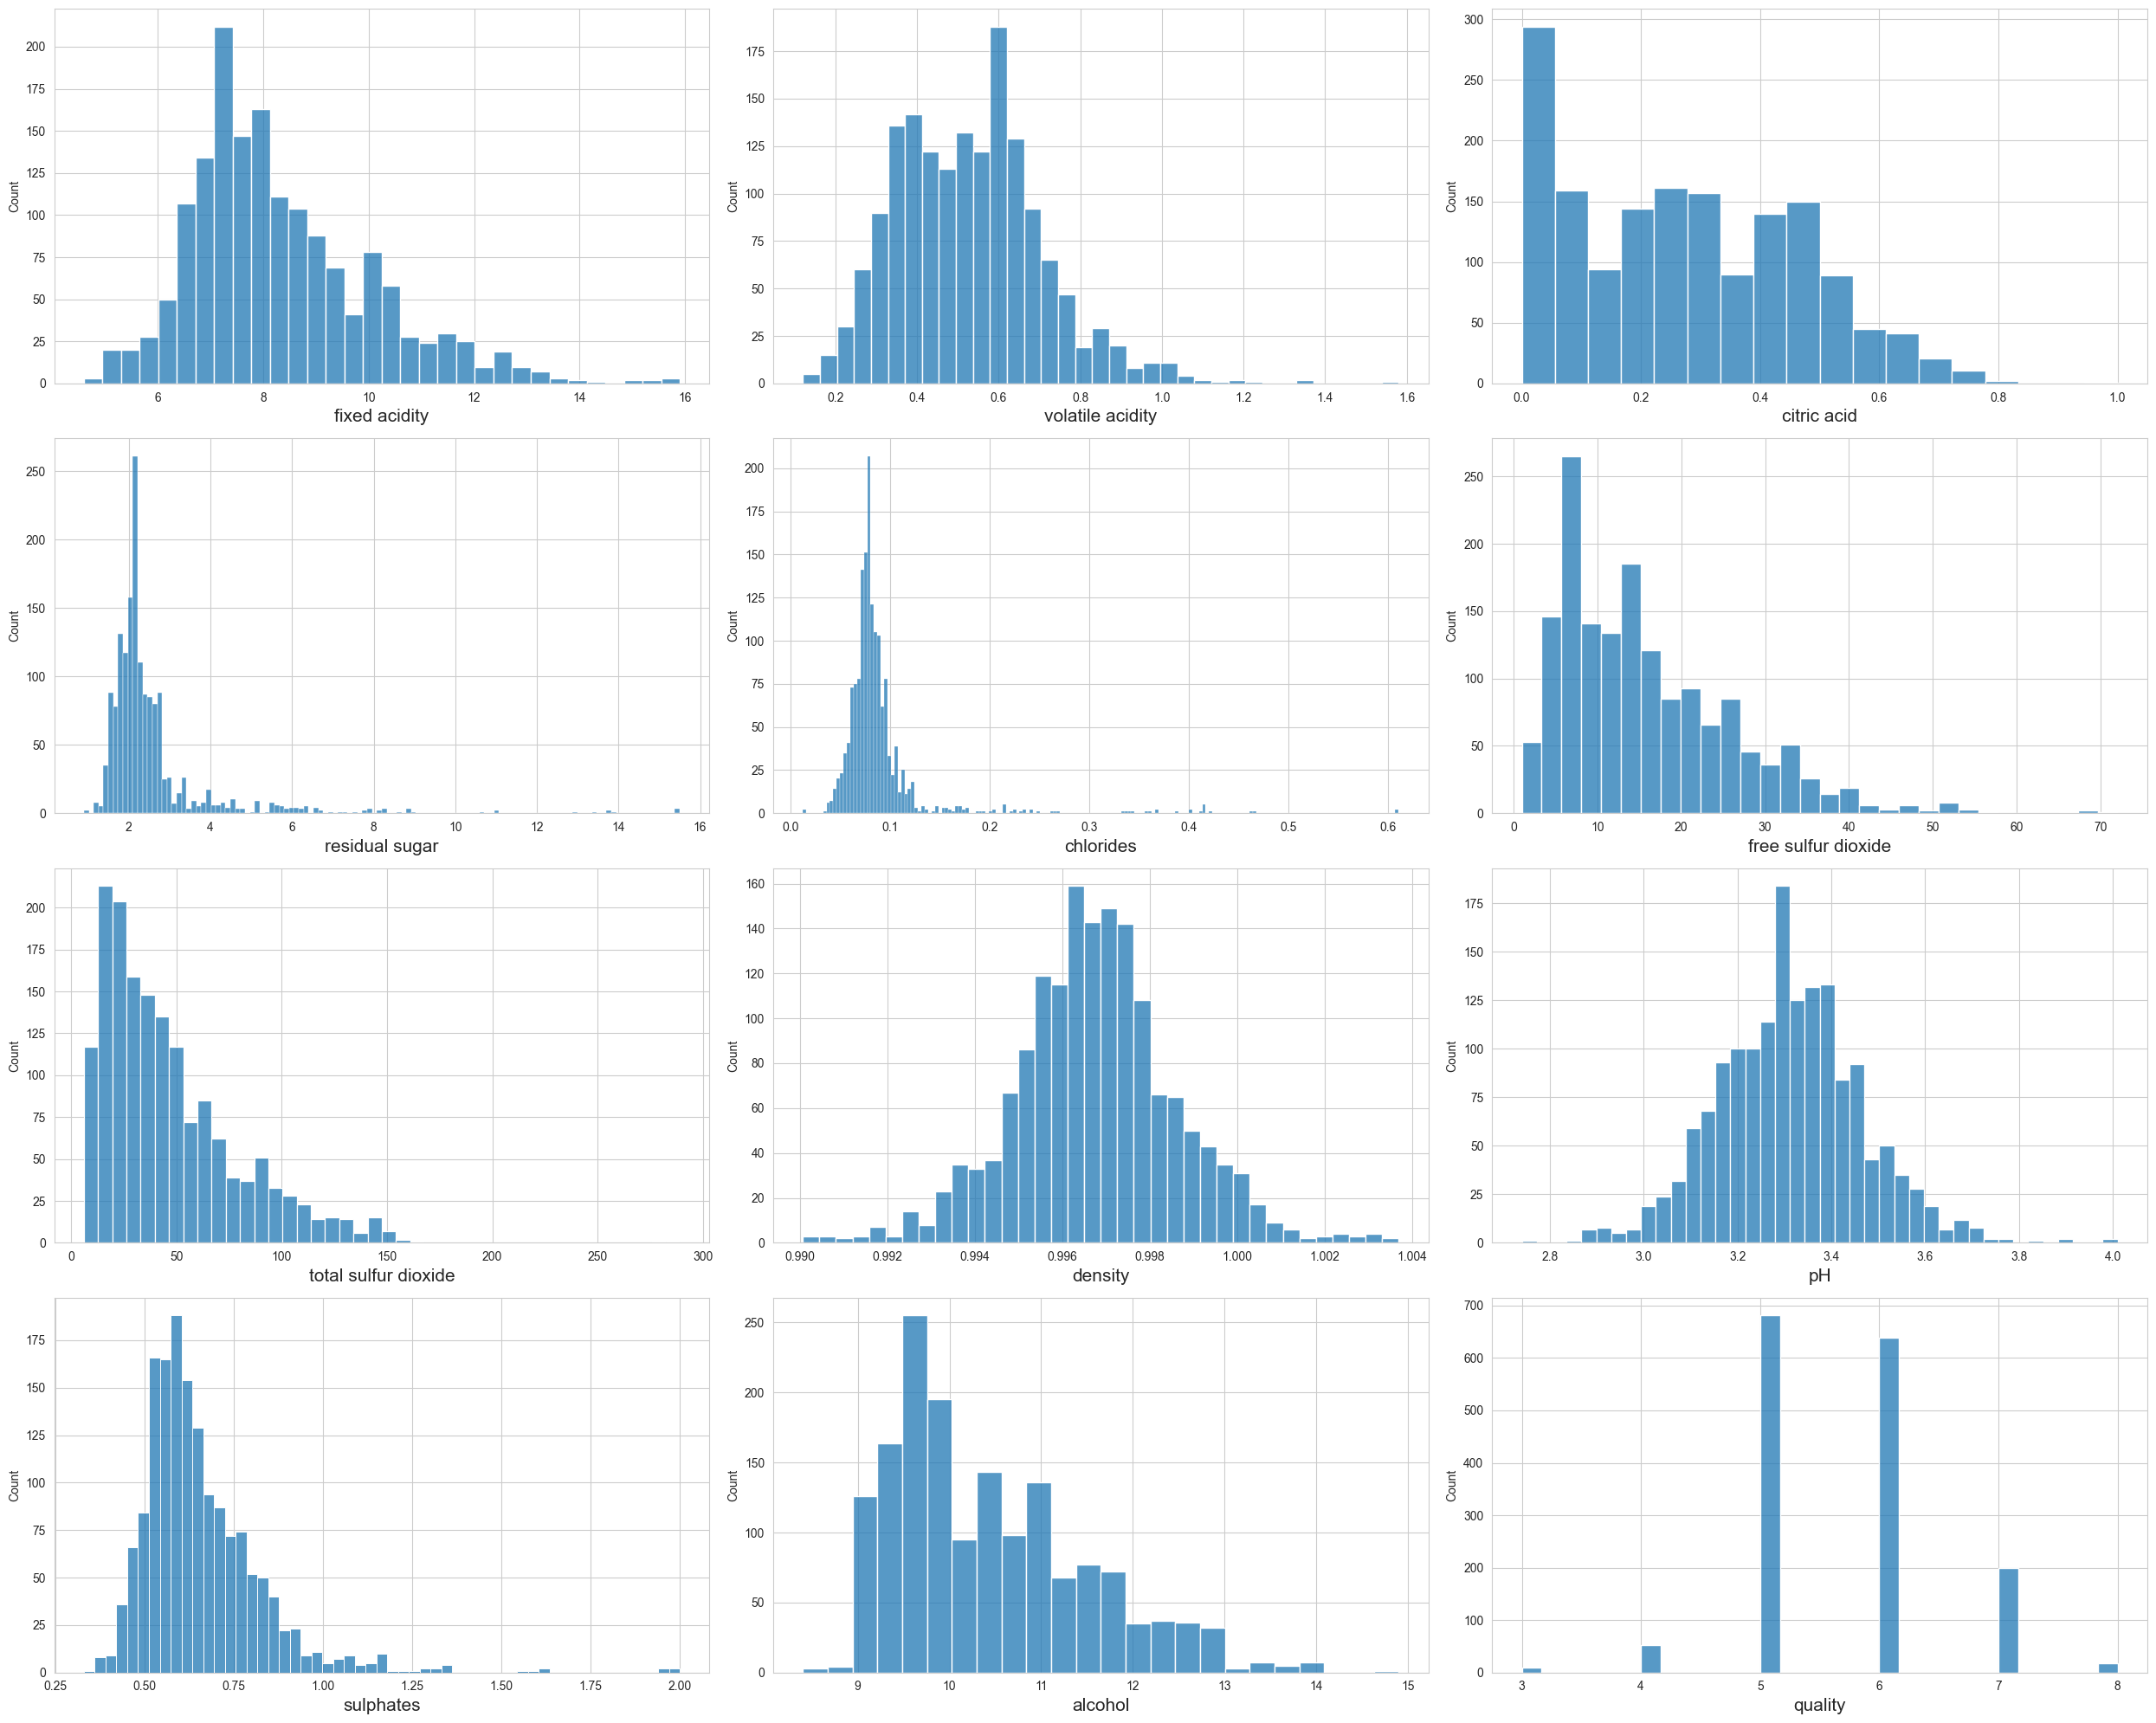

In [ ]:
# let's see how data is distributed for every column
plt.figure(figsize = (25, 20))
plotnumber = 1

for col in df:
    if plotnumber <= 12:
        ax = plt.subplot(4, 3, plotnumber)
        sns.histplot(df[col])
        plt.xlabel(col, fontsize = 15)

    plotnumber += 1

plt.tight_layout()
plt.show()

### Q4. correlation plot을 그리고, 해당 plot에서 얻은 인사이트를 정리해보세요.

더불어 multicollinearity(통계학의 회귀분석에서 독립변수들 간에 강한 상관관계가 나타나는 문제)에 주목하여, 해당 correlation plot에서 어떤 영향을 주고 있는지 있는지 예를 들어 기술하시오.

답: 다중공선성 문제가 있는 변수들의 경우 높은 상관관계가 나타나고 있으며, 아래의 heatmap에서는 강한 양의 상관관계가 나타날 때는 흰색에 가깝게, 강한 음의 상관관계가 나타날 때는 검정색에 가깝게 상관행렬이 나타나있다. 예를 들어 crtic acid 과 fixed acidity 간에는 0.67의 높은 상관관계가 나타나있으며 그 칸이 흰색에 가깝게 칠해져있다.

한편 이런 높은 양의 상관관계는 두 변수가 서로 유사한 정보를 포함하고 있을 가능성을 의미하며, 동시에 회귀 모델에 포함될 경우 회귀계수의 분산이 증가하고 계수 추정의 불안정성을 초래할 수 있다.



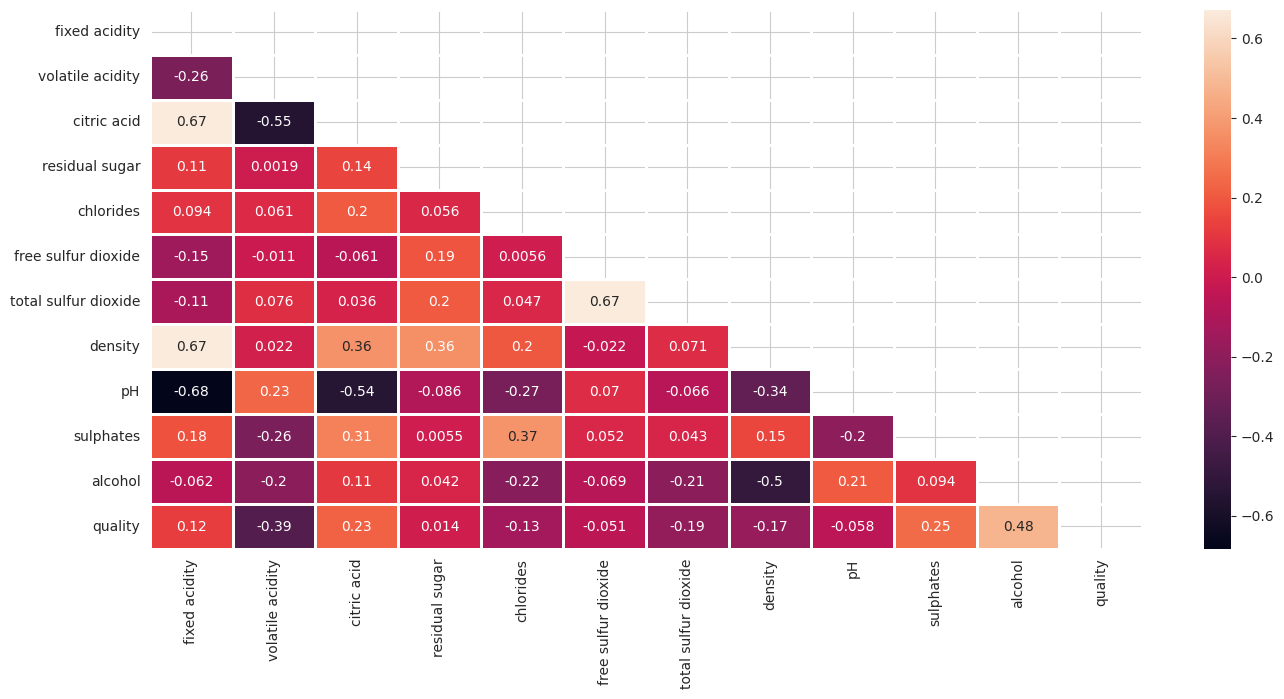

In [16]:
# 상관관계 plot
plt.figure(figsize = (16, 7))

corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype = bool))

sns.heatmap(corr, mask = mask, annot = True, fmt = '0.2g', linewidths = 1)
plt.show()

In [17]:
#Pearson correlation coefficient
import scipy.stats as st
print("Pearson correlation coefficient:", st.pearsonr(df["alcohol"],df["density"]))
print("Pearson correlation coefficient:", st.pearsonr(df["free sulfur dioxide"],df["total sulfur dioxide"]))
print("Pearson correlation coefficient:", st.pearsonr(df["fixed acidity"],df["pH"]))
print("Pearson correlation coefficient:", st.pearsonr(df["citric acid"],df["pH"]))
print("Pearson correlation coefficient:", st.pearsonr(df["fixed acidity"],df["density"]))

Pearson correlation coefficient: PearsonRResult(statistic=np.float64(-0.4961797702417016), pvalue=np.float64(3.938835339988381e-100))
Pearson correlation coefficient: PearsonRResult(statistic=np.float64(0.6676664504810215), pvalue=np.float64(6.404722954681827e-207))
Pearson correlation coefficient: PearsonRResult(statistic=np.float64(-0.6829781945685315), pvalue=np.float64(4.06303403984401e-220))
Pearson correlation coefficient: PearsonRResult(statistic=np.float64(-0.5419041447395098), pvalue=np.float64(1.0072013259111972e-122))
Pearson correlation coefficient: PearsonRResult(statistic=np.float64(0.6680472921189734), pvalue=np.float64(3.0747470608610657e-207))


### Q5. quality range를 두 파트로 나눠보세요.
회귀문제를 분류 문제로 바꾸는 과정.
참고로 quality를 분류하는 문제이므로 qualtiy가 종속변수임.

In this dataset quality range is between 3 and 8
We will divide quality range into two parts:



*   High quality wine: 6 - 8
*   Low quality wine: 3 - 5



In [18]:
df["quality"] = df["quality"].apply(lambda x: 1 if x >= 6 else 0)
df["quality"]

,quality
0,0
1,0
2,0
3,1
4,0
...,...
1594,0
1595,1
1596,1
1597,0


In [19]:
#데이터의 값 크기를 직관적으로 파악하기 위해, 셀 배경색을 값에 따라 그라데이션으로 시각화하는 함수.
df.head().style.background_gradient(cmap = "Reds")

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.400000,0.700000,0.000000,1.900000,0.076000,11.000000,34.000000,0.997800,3.510000,0.560000,9.400000,0
1,7.800000,0.880000,0.000000,2.600000,0.098000,25.000000,67.000000,0.996800,3.200000,0.680000,9.800000,0
2,7.800000,0.760000,0.040000,2.300000,0.092000,15.000000,54.000000,0.997000,3.260000,0.650000,9.800000,0
3,11.200000,0.280000,0.560000,1.900000,0.075000,17.000000,60.000000,0.998000,3.160000,0.580000,9.800000,1
4,7.400000,0.700000,0.000000,1.900000,0.076000,11.000000,34.000000,0.997800,3.510000,0.560000,9.400000,0


### Q6. 종속변수(y,label)은 무엇이 되어야 하나요?

eda를 어느정도 마친 뒤에는 어떤 변수가 종속 변수이고 어떤 변수가 독립변수인지 지정해야함. (여러 피처 중 제거할 피처도 선택해야함)

이후에 train data set과 test data set을 설정.


In [21]:
# we select dependent variable (label)
y = df["quality"]

# we select independent variable
x = df.drop("quality", axis = 1)

In [23]:
# splitting data into training and test set
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y,
                                                    test_size = 0.25,
                                                    shuffle = True,
                                                    random_state = 1)

### Q7. 왜 Standardization(StandardScaler, MinMaxScaler 등) 사용할까요?
두 Scaler의 특징에 대해 조사하고, 보다 적절한 Scaler가 무엇일지 그 이유와 함께 적어주세요.

답:

- standardscaler - x' = (x − mean) / standard deviation. 각 변수를 평균 0, 분산 1이 되도록 변환. 정규분포에 가까운 데이터에서 효과적, 이상치에 상대적으로 민감
.

- minmaxscaler - x' = (x − min) / (max − min). 데이터를 0과 1사이로 정규화. 데이터를 0과 1 사이로 정규화. 값의 범위를 직관적으로 유지. 이상치가 존재할 경우 전체 스케일이 크게 왜곡될 수 있음.

- 이 데이터의 경우 rightskewed distribution 및 이상치가 관찰되기 때문에 분포 무관한 minmaxscaler가 유리하며 경사하강법이 안정적으로 작동되기에 이 방법을 적용함.





In [29]:
# scaling data
from sklearn.preprocessing import MinMaxScaler

norm = MinMaxScaler(feature_range = (0, 1))
norm.fit(x_train)
x_train = norm.transform(x_train)
x_test = norm.transform(x_test)

### Q7-2. 위의 코드에서, train dataset에 대해서는 fit_transform을, test dataset에 대해서는 transform을 실시하는 이유가 무엇일지 조사해주세요.
답 : test data는 학습에 사용되면 안되기 때문에, 모델은 test data로부터는 어떤 정보도 배우면(fit) 안된다.

fit transform 은 데이터에서 기준을 학습하여 값을 변환한다. 평균, 표준편차와 같은 값을 학습하여 변환한다. 반면 transform 은 이미 배운 기준으로 값만 변환하며 새로운 정보는 학습하지 않는다.

test dataset에 fit transform 을 실시하면 모델이 train dataset의 정보를 미리 알아버리기 때문에(data leakage) 평가 성능이 부풀려지므로, test dataset에는 fit transform 을 실시하면 안된다.

In [24]:
#x_train, x_test
print(x_train[0:5])
print("\n")
print(x_train.shape)
print("_________________________________________________________________________")
print(x_test[0:5])
print("\n")
print(x_test.shape)

      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
1144            7.3             0.320         0.23             2.3      0.066   
73              8.3             0.675         0.26             2.1      0.084   
446            12.5             0.380         0.60             2.6      0.081   
399             8.7             0.765         0.22             2.3      0.064   
647             8.3             0.845         0.01             2.2      0.070   

      free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
1144                 35.0                  70.0  0.99588  3.43       0.62   
73                   11.0                  43.0  0.99760  3.31       0.53   
446                  31.0                  72.0  0.99960  3.10       0.73   
399                   9.0                  42.0  0.99630  3.10       0.55   
647                   5.0                  14.0  0.99670  3.32       0.58   

      alcohol  
1144     10.1  
73        9.2  
44

In [26]:
print(y_train.head())
print(y_train.shape)
print("___________________________")
print(y_test.head())
print(y_test.shape)

1144    0
73      0
446     0
399     0
647     0
Name: quality, dtype: int64
(1199,)
___________________________
75      0
1283    1
408     1
1281    1
1118    1
Name: quality, dtype: int64
(400,)


### Q8. Building Classification models

이번 코드에서는 non parametric model; knn을 사용하여 train, test 진행해보았습니다.

아래의 코드 외에도 원하는 한가지 classification 모델(KNN 제외)을 선정하여 아래의 과정을 반복하고, 그 결과를 해석하세요. grid search 과정은 거치지 않고 임의의 파라미터값으로 진행해도 좋습니다.

아래와 같은 Kaggle 코드들도 참고해보세요.  
- https://www.kaggle.com/code/melissamonfared/red-wine-quality-prediction-eda-classification/notebook
- https://www.kaggle.com/code/eisgandar/red-wine-quality-eda-classification


# ***KNN 모델링 과정***

**1. 실제 test dataset을 사용하기 전에, train dataset만을 이용해 여러 설정을 시험(grid search)해보고 가장 좋은 하이퍼파라미터를 찾는 과정**

In [32]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
#KNN

knn = KNeighborsClassifier()  #기본설정의 KNN 분류기 객체를 만든 것. data train 전 모델 틀.

knn_params = {"n_neighbors": np.arange(2, 50), #이웃 k를 2~49까지 바꿔가며 시도.
             "weights": ["uniform", "distance"], #가까운 이웃에 더 가중치를 줄지/동일하게 줄지
             "leaf_size": [25, 30, 25]} #탐색 구조 성능 관련 파라미터

knn_cv_model = GridSearchCV(knn, knn_params, cv = 10) #gridsearch: 여러 설정을 자동으로 시험해보는 도구, cv=10 데이터를 10번 나누는 것.
knn_cv_model.fit(x_train, y_train)

GridSearchCV(cv=10, estimator=KNeighborsClassifier(),
             param_grid={'leaf_size': [25, 30, 25],
                         'n_neighbors': array([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
       19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
       36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49]),
                         'weights': ['uniform', 'distance']})

In [33]:
#위에서 시험해본 설정 중 좋은 설정을 찾는 것이 목표.
print("Best score for train set: " + str(knn_cv_model.best_score_))

print("____________________________________________")

print("best K value: " + str(knn_cv_model.best_params_["n_neighbors"]),
     "\nbest weights: " + knn_cv_model.best_params_["weights"],
     "\nbest leaf size: " + str(knn_cv_model.best_params_["leaf_size"]))

Best score for train set: 0.798172268907563
____________________________________________
best K value: 21 
best weights: distance 
best leaf size: 25


**2. GrindsearchCV로 찾은 최적의 하이퍼파라미터를 사용해서 train dataset 전체로 최종 모델을 다시 학습시키는 단계**

In [34]:
knn_model = KNeighborsClassifier(n_neighbors = knn_cv_model.best_params_["n_neighbors"],
                                leaf_size = knn_cv_model.best_params_["leaf_size"],
                                weights = knn_cv_model.best_params_["weights"])

knn_model.fit(x_train, y_train)

KNeighborsClassifier(leaf_size=25, n_neighbors=np.int64(21), weights='distance')

**3. test data로 예측 & accuracy 로 모델 성능/정확도 평가**

In [ ]:
from sklearn.metrics import accuracy_score
y_pred = knn_model.predict(x_test)
print("Accuracy:",accuracy_score(y_test, y_pred)) #Validation Set Accurac

#accuracy 약 0.8로 test data 400개 중 약 80% 정확히 맞춤.

Accuracy: 0.8025


In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

#precision: low(high) quality라고 예측한 것 중 78%(82%)가 low(high)
#recall: 둘다 low quality, high quality 중 약 80% 정도를 예측
#f1 score: precision과 recall의 균형

              precision    recall  f1-score   support

           0       0.78      0.81      0.79       188
           1       0.82      0.80      0.81       212

    accuracy                           0.80       400
   macro avg       0.80      0.80      0.80       400
weighted avg       0.80      0.80      0.80       400



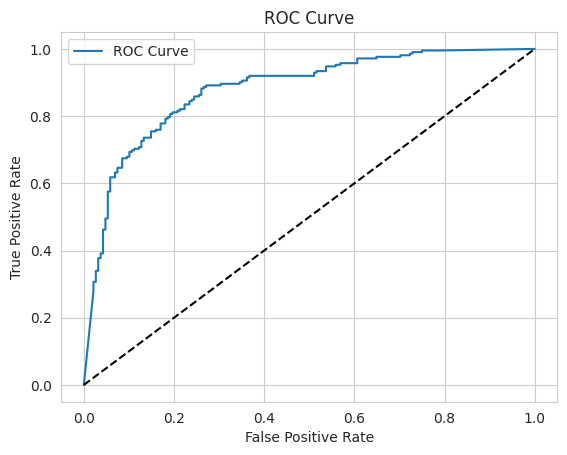

In [46]:
from sklearn.metrics import roc_curve, roc_auc_score
# Validation Set 에 대한 예측확률 계산
y_prob = knn_model.predict_proba(x_test)[:,1]


# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label = "ROC Curve")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

#아래 ROC커브가 대각선보다 뚜렷하게 위쪽에 위치, 모델이 효과적으로 quality 구별을 한다고 볼 수 있음.

In [45]:
#auc score
auc = roc_auc_score(y_test, y_prob)
print(auc)

#auc score 도 0.87로 강한 분류 성능을 가지고 있다고 볼 수 있음.

0.8789140907266157


# ***SVC 모델링 과정***

In [30]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import roc_curve, roc_auc_score

**1. 실제 test dataset을 사용하기 전에, train dataset만을 이용해 여러 설정을 시험(grid search)해보고 가장 좋은 하이퍼파라미터를 찾는 과정**

In [37]:
pipe = Pipeline([
    ("scaler", MinMaxScaler(feature_range=(0, 1))),
    ("svc", SVC(probability=True, random_state=42))
])

param_grid = [
    {
        "svc__kernel": ["rbf"],
        "svc__C": [0.1, 1, 10, 100],
        "svc__gamma": ["scale", "auto", 0.01, 0.1, 1],
        "svc__class_weight": [None, "balanced"],
    },
    {
        "svc__kernel": ["linear"],
        "svc__C": [0.1, 1, 10, 100],
        "svc__class_weight": [None, "balanced"],
    }
]

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

svc_cv_model = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=cv,
    scoring="accuracy",   # 원하면 "roc_auc"로 바꿀 수도 있음
    n_jobs=-1
)

#trainset으로 튜닝
svc_cv_model.fit(x_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=10, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('scaler', MinMaxScaler()),
                                       ('svc',
                                        SVC(probability=True,
                                            random_state=42))]),
             n_jobs=-1,
             param_grid=[{'svc__C': [0.1, 1, 10, 100],
                          'svc__class_weight': [None, 'balanced'],
                          'svc__gamma': ['scale', 'auto', 0.01, 0.1, 1],
                          'svc__kernel': ['rbf']},
                         {'svc__C': [0.1, 1, 10, 100],
                          'svc__class_weight': [None, 'balanced'],
                          'svc__kernel': ['linear']}],
             scoring='accuracy')

In [38]:
#위에서 시험한 설정 중 가장 점수가 높은 하이퍼파라미터 출력
print("Best score for train set (CV mean):", svc_cv_model.best_score_)
print("____________________________________________")
print("Best params:", svc_cv_model.best_params_)

Best score for train set (CV mean): 0.7731652661064425
____________________________________________
Best params: {'svc__C': 10, 'svc__class_weight': None, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}


**2. GrindsearchCV로 찾은 최적의 하이퍼파라미터를 사용해서 train dataset 전체로 최종 모델을 다시 학습시키는 단계**

In [39]:
best_svc_model = svc_cv_model.best_estimator_

**3. test data로 예측 & accuracy 로 모델 성능/정확도 평가**

In [40]:
y_pred = best_svc_model.predict(x_test)
print("Accuracy:", accuracy_score(y_test, y_pred)) #분류 정확도 약 73%, knn보다 낮은 정확도.
print(classification_report(y_test, y_pred)) #knn과 마찬가지로 고품질에 대한 precision이 더 높음.

Accuracy: 0.735
              precision    recall  f1-score   support

           0       0.70      0.75      0.73       188
           1       0.77      0.72      0.74       212

    accuracy                           0.73       400
   macro avg       0.73      0.74      0.73       400
weighted avg       0.74      0.73      0.74       400



ROC AUC: 0.8140430549979927


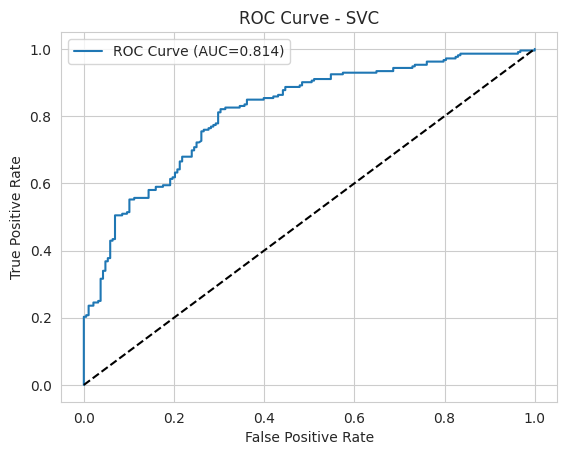

In [42]:
y_prob = best_svc_model.predict_proba(x_test)[:, 1]
auc = roc_auc_score(y_test, y_prob)
print("ROC AUC:", auc)

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label=f"ROC Curve (AUC={auc:.3f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVC")
plt.legend()
plt.show()

#roc 커프가 왼쪽 위에 가까워지는 성향이 있으며, auc가 0.8 정도로 모델이 꽤 좋은 분류 성능을 가지고 있다고 판단할 수 있음.
#그러나 knn 모델과 비교하였을 때는 비교적 낮은 분류 성능을 가지고 있다고 볼 수 있음.